# Part 2: Scalable Data Generation for Foundation Model Training

Foundation models require diverse, large-scale datasets spanning many operating
conditions. This notebook demonstrates how ANDES can be used to generate such
datasets programmatically through parameter sweeps, contingency enumeration,
and batch parallel execution.

Three approaches are covered, from simple in-memory loops to fully parallel
batch processing.

## Setup

In [ ]:
%pip install -q andes
%matplotlib inline

import logging

import numpy as np
from matplotlib import pyplot as plt

import andes
andes.config_logger(stream_level=30)  # reduce verbosity for batch runs
logging.getLogger('andes').propagate = False

## Approach 1: In-Memory Parameter Sweeps

For quick exploratory studies, parameters can be swept in a Python loop.
The following example varies load levels and records the resulting voltage
profiles from power flow. This type of sweep produces the steady-state
snapshots that a foundation model might use for pretraining.

In [2]:
kundur = andes.get_case('kundur/kundur_full.xlsx')
ss = andes.run(kundur, no_output=True, default_config=True, verbose=30)

# Define sweep range
n_samples = 8
pq0_values = np.linspace(8, 15, n_samples)

# Storage for results
v_results = np.zeros((ss.Bus.n, n_samples))

for i, p0 in enumerate(pq0_values):
    ss.PQ.set('p0', 'PQ_0', p0, base='device')
    ss.PFlow.run()
    v_results[:, i] = ss.dae.y[ss.Bus.v.a]

print(f"Completed {n_samples} power flow calculations")
print(f"Result array shape: {v_results.shape} (buses x scenarios)")

Completed 8 power flow calculations
Result array shape: (10, 8) (buses x scenarios)


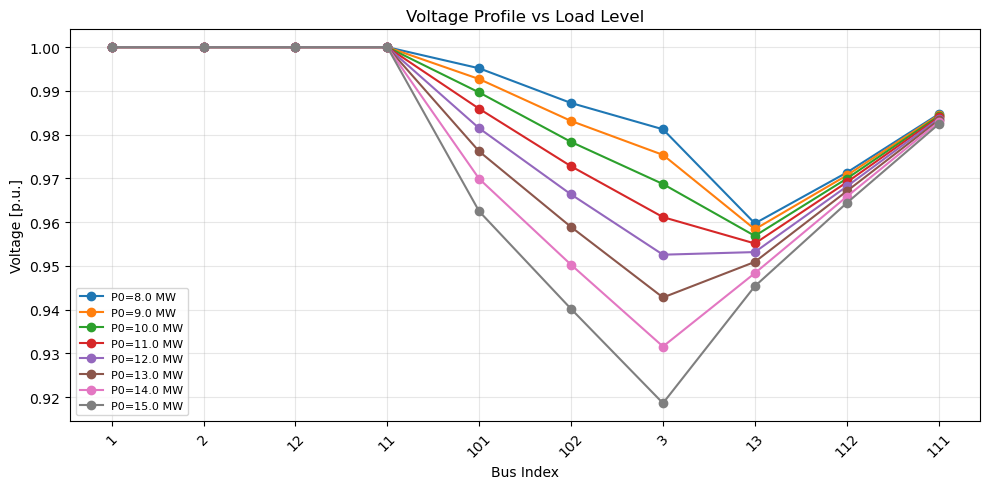

In [3]:
plt.figure(figsize=(10, 5))
for i in range(n_samples):
    plt.plot(v_results[:, i], 'o-', label=f'P0={pq0_values[i]:.1f} MW')

plt.xlabel('Bus Index')
plt.ylabel('Voltage [p.u.]')
plt.title('Voltage Profile vs Load Level')
plt.legend(fontsize=8)
plt.xticks(range(ss.Bus.n), ss.Bus.name.v, rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Approach 2: Contingency Enumeration for Dynamic Trajectories

For time-domain data, each contingency scenario generates a trajectory.
The following example trips each line in turn (N-1 contingency screening)
and records the generator frequency response. Each trajectory constitutes
one training sample for a dynamic foundation model.

In [4]:
# Identify all lines in the system
ss_ref = andes.load(kundur, setup=False)
all_lines = ss_ref.Line.idx.v
print(f"Total lines: {len(all_lines)}")
print(f"Line indices: {all_lines}")

# Select a subset for demonstration (3 lines)
lines_to_test = all_lines[:3]

Total lines: 15
Line indices: ['Line_0', 'Line_1', 'Line_2', 'Line_3', 'Line_4', 'Line_5', 'Line_6', 'Line_7', 'Line_8', 'Line_9', 'Line_10', 'Line_11', 'Line_12', 'Line_13', 'Line_14']


In [5]:
trajectories = {}

for line_idx in lines_to_test:
    # Fresh system for each scenario
    ss = andes.load(kundur, setup=False)

    # Trip line at t=1.0s, reclose at t=1.5s
    ss.add('Toggle', model='Line', dev=line_idx, t=1.0)
    ss.add('Toggle', model='Line', dev=line_idx, t=1.5)

    ss.setup()
    ss.Toggle.set_status(1, 0)  # disable pre-existing Toggle

    ss.PFlow.run()
    ss.TDS.config.tf = 5
    ss.TDS.config.no_tqdm = 1
    ss.TDS.run()

    # Extract time series
    omega_df = ss.TDS.get_timeseries(ss.GENROU.omega)
    trajectories[line_idx] = omega_df
    print(f"  {line_idx}: {omega_df.shape[0]} time steps, "
          f"{omega_df.shape[1]} generators")

  Line_0: 157 time steps, 4 generators
  Line_1: 157 time steps, 4 generators
  Line_2: 157 time steps, 4 generators


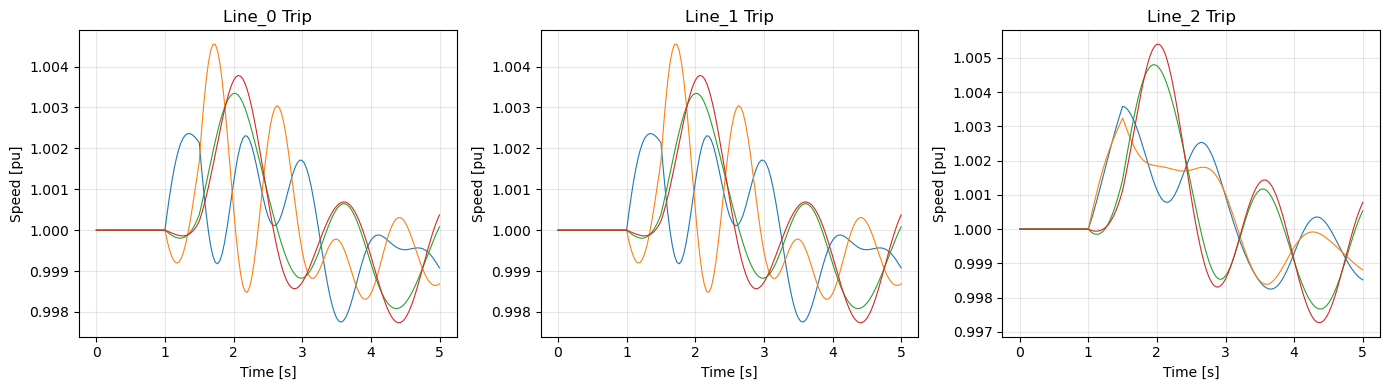

In [6]:
fig, axes = plt.subplots(1, len(trajectories), figsize=(14, 4))

for ax, (line_idx, omega_df) in zip(axes, trajectories.items()):
    for col in omega_df.columns:
        ax.plot(omega_df.index, omega_df[col], linewidth=0.8)
    ax.set_title(f'{line_idx} Trip')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Speed [pu]')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Approach 3: Parallel Batch Processing

For large-scale data generation (hundreds or thousands of scenarios),
ANDES distributes case files across multiple CPU cores. This approach
is recommended for production dataset generation.

The workflow consists of two phases:
1. Generate case files programmatically with varied parameters
2. Run all cases in parallel using the built-in multiprocessing

In [7]:
import os
import shutil

os.makedirs('batch_cases', exist_ok=True)

# Generate cases with different load levels
ss = andes.load(kundur)
p0_base = ss.PQ.get('p0', 'PQ_0')

N_CASES = 4
p0_values = np.linspace(p0_base, 1.3 * p0_base, N_CASES)

for value in p0_values:
    ss.PQ.set('p0', 'PQ_0', value, base='device')
    file_name = f'batch_cases/kundur_p_{value:.2f}.xlsx'
    andes.io.dump(ss, 'xlsx', file_name, overwrite=True)
    print(f"Created: {file_name}")

Created: batch_cases/kundur_p_11.59.xlsx
Created: batch_cases/kundur_p_12.75.xlsx
Created: batch_cases/kundur_p_13.91.xlsx
Created: batch_cases/kundur_p_15.07.xlsx


In [8]:
# Run all cases in parallel and return System objects
systems = andes.run('batch_cases/*.xlsx', routine='tds', pool=True, verbose=30)

print(f"\nCompleted {len(systems)} simulations in parallel")


Completed 4 simulations in parallel


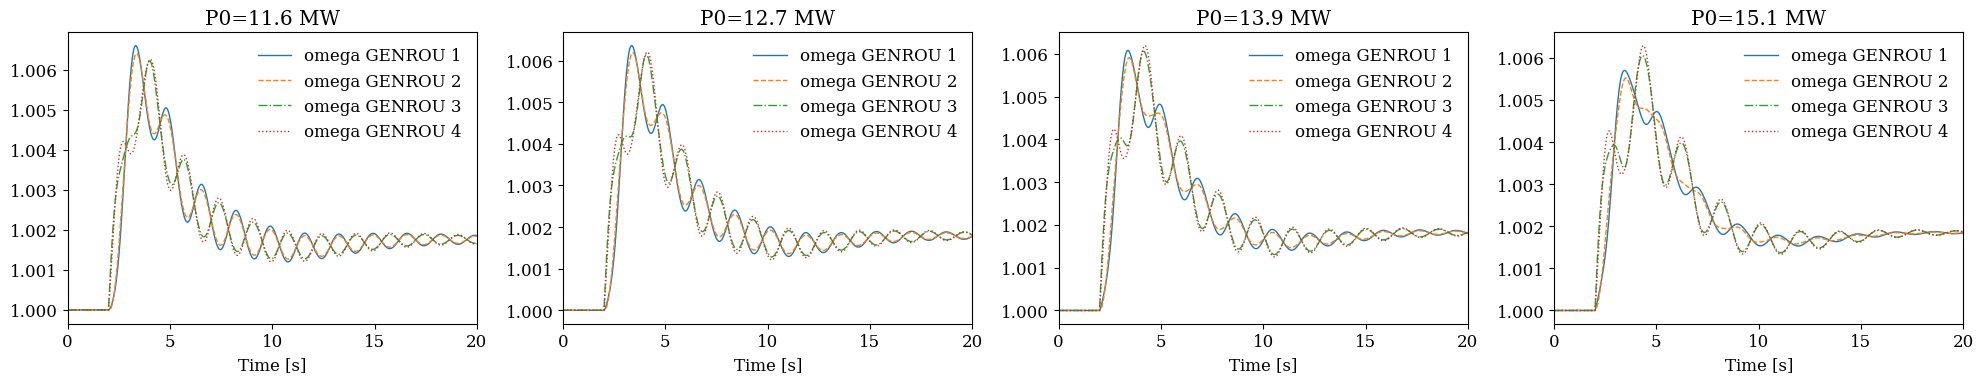

In [14]:
fig, axes = plt.subplots(1, len(systems), figsize=(20, 4))

for i, sys in enumerate(systems):
    sys.TDS.plt.plot(sys.GENROU.omega, fig=fig, ax=axes[i],
                     title=f'P0={p0_values[i]:.1f} MW',
                     latex=False, show=False)

plt.tight_layout()
plt.show()

## Data Export for ML Pipelines

The simulation results can be exported in formats directly compatible
with ML training pipelines. The key data structures are NumPy arrays
and pandas DataFrames.

In [15]:
# Example: export one trajectory as a NumPy array for a DataLoader
sys = systems[0]

# State variables (generator internal states)
x_data = np.array(sys.dae.ts.x)    # shape: (n_steps, n_states)

# Algebraic variables (bus voltages, angles)
y_data = np.array(sys.dae.ts.y)    # shape: (n_steps, n_algebs)

# Time vector
t_data = np.array(sys.dae.ts.t)    # shape: (n_steps,)

print(f"States (x):    {x_data.shape}")
print(f"Algebraics (y): {y_data.shape}")
print(f"Time steps:     {len(t_data)}")
print(f"\nTotal data points per trajectory: {x_data.size + y_data.size:,}")

States (x):    (603, 52)
Algebraics (y): (603, 144)
Time steps:     603

Total data points per trajectory: 118,188


In [16]:
# Save as compressed NumPy archive for later loading
np.savez_compressed(
    'sample_trajectory.npz',
    t=t_data,
    x=x_data,
    y=y_data,
)
print("Saved to sample_trajectory.npz")

# Verify: loading it back
data = np.load('sample_trajectory.npz')
print(f"Keys: {list(data.keys())}")
print(f"Loaded x shape: {data['x'].shape}")

Saved to sample_trajectory.npz
Keys: ['t', 'x', 'y']
Loaded x shape: (603, 52)


## Scaling Up: A Recipe for Large Datasets

For foundation model pretraining, the following recipe can be applied:

1. **Select a base system** (e.g., IEEE 14-bus, 118-bus, or a synthetic case)
2. **Define variation axes**: load levels, generation dispatch, topology (N-1), fault locations, renewable penetration
3. **Generate case files** by combining variations (grid search or Latin Hypercube sampling)
4. **Run in parallel**: `andes run cases/*.xlsx -r tds --ncpu N`
5. **Collect outputs**: each run produces `.npz` files with full time series

For a system with 10 load levels, 5 dispatch patterns, and 20 contingencies,
this produces 1,000 trajectories. On a 24-core workstation, the entire
IEEE 14-bus dataset can be generated in minutes.

## Cleanup

In [17]:
shutil.rmtree('batch_cases', ignore_errors=True)
os.remove('sample_trajectory.npz') if os.path.exists('sample_trajectory.npz') else None
!andes misc -C

No output file found in the working directory.
